In [40]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
import sys,os
from importlib import reload


In [41]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize and reshape for CNN
x_train = x_train.reshape(-1,28,28,1)/255.0 #-1 get the nuber of hw many image we have better tha we put 60000
x_test = x_test.reshape(-1,28,28,1)/255.0# 1 for grayscale if rgb we put 3

print(x_train.shape, y_train.shape)

(60000, 28, 28, 1) (60000,)


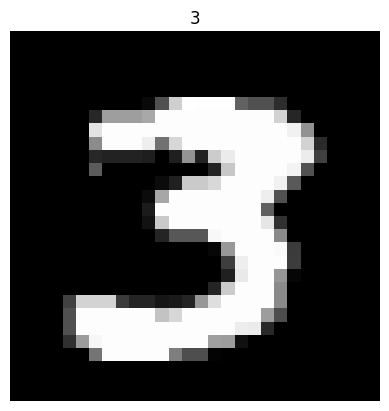

In [42]:
#some examples
plt.imshow(x_train[27], cmap='gray')
plt.title(str(y_train[27]))
plt.axis('off')
plt.show()

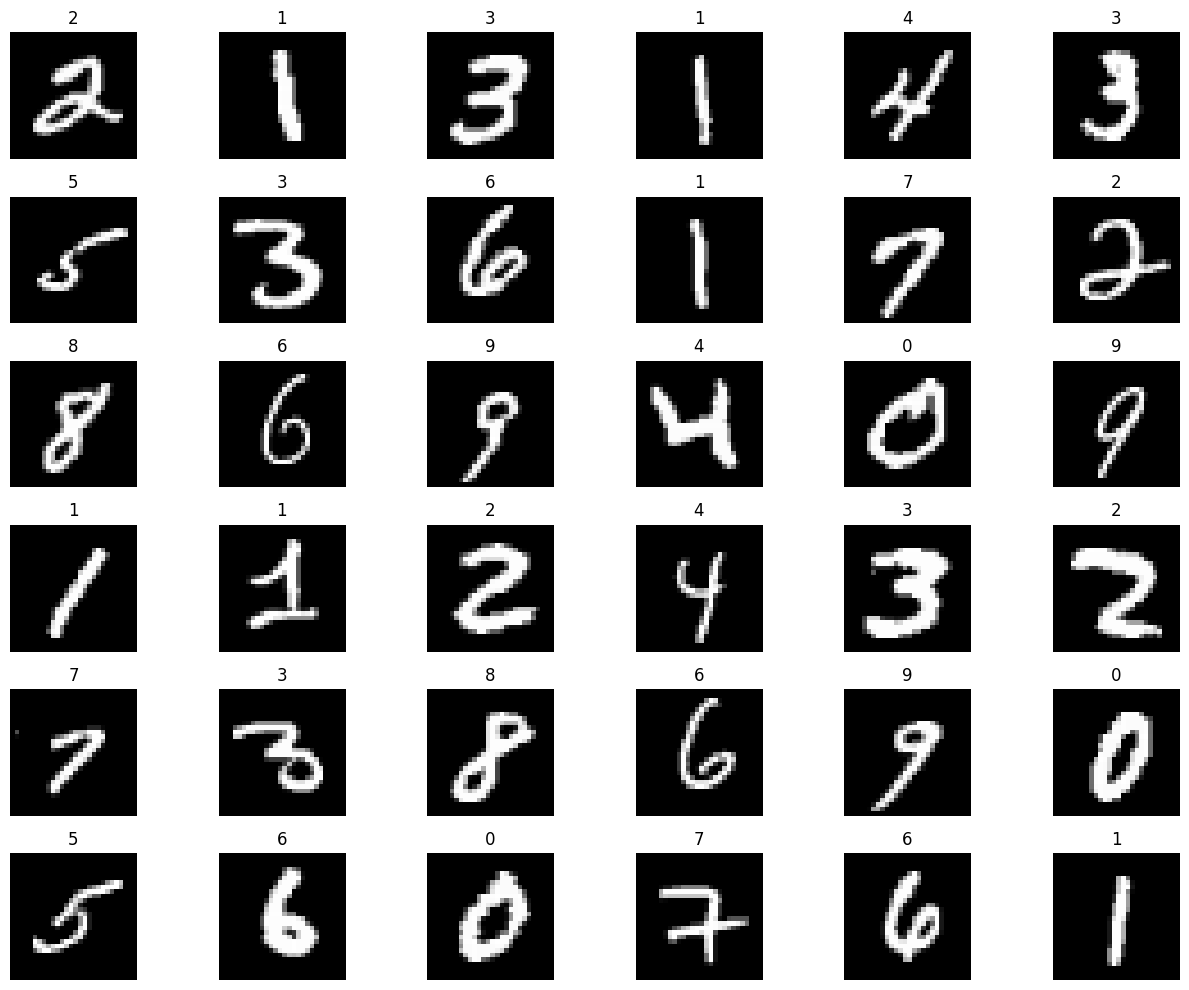

In [43]:

imgs = x_train[5:41]
labels = y_train[5:41]

plt.figure(figsize=(13,10))
for i in range(len(imgs)):
    plt.subplot(6,6,i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(labels[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
hidden1=100
hidden2=100
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),           # prevents overfitting
    Dense(10, activation='softmax')  # 10 classes
])


In [45]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # << must be sparse if labels are integers
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,           # integers
    batch_size=512,
    epochs=16,
    validation_data=(x_test, y_test)  # integers
)

Epoch 1/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 52s 427ms/step - accuracy: 0.8366 - loss: 0.5468 - val_accuracy: 0.9680 - val_loss: 0.1069
Epoch 2/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 85s 449ms/step - accuracy: 0.9578 - loss: 0.1441 - val_accuracy: 0.9793 - val_loss: 0.0634
Epoch 3/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 449ms/step - accuracy: 0.9680 - loss: 0.1100 - val_accuracy: 0.9824 - val_loss: 0.0547
Epoch 4/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 50s 423ms/step - accuracy: 0.9747 - loss: 0.0857 - val_accuracy: 0.9859 - val_loss: 0.0443
Epoch 5/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 80s 408ms/step - accuracy: 0.9776 - loss: 0.0757 - val_accuracy: 0.9874 - val_loss: 0.0377
Epoch 6/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 83s 418ms/step - accuracy: 0.9808 - loss: 0.0646 - val_accuracy: 0.9867 - val_loss: 0.0381
Epoch 7/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 80s 402ms/step - accuracy: 0.9833 - loss: 0.0583 - val_accuracy: 0.9892 - val_loss: 0.0324
Epoch 8/16
118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 405ms/step - accuracy: 0.9844 - loss: 0

In [50]:
score=model.evaluate(x_test,y_test,verbose =0)
print(f'test loss:{score[0]:4.4f}')
print(f'test accuracy:{score[1]:4.4f}')

test loss:0.0269
test accuracy:0.9914


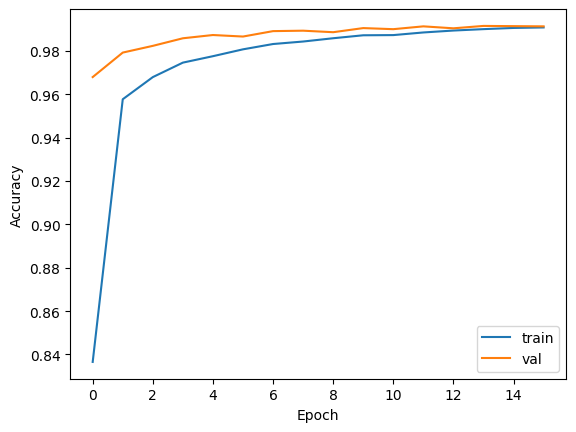

In [51]:

acc = history.history['accuracy']
val_acc = history.history.get('val_accuracy')

plt.plot(acc, label='train')
if val_acc:
    plt.plot(val_acc, label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

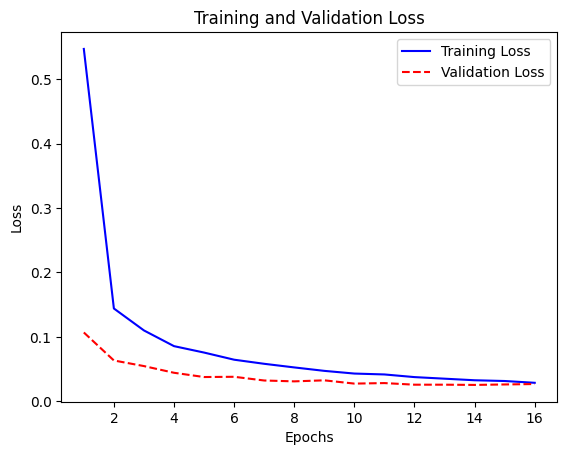

In [52]:

loss = history.history['loss']              # training loss
val_loss = history.history.get('val_loss')  # validation loss (might be None if no val data)

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b-', label='Training Loss')
if val_loss:
    plt.plot(epochs, val_loss, 'r--', label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# **Plot results**


In [61]:
y_sigmoid=model.predict(x_test)
y_pred=np.argmax(y_sigmoid,axis=-1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


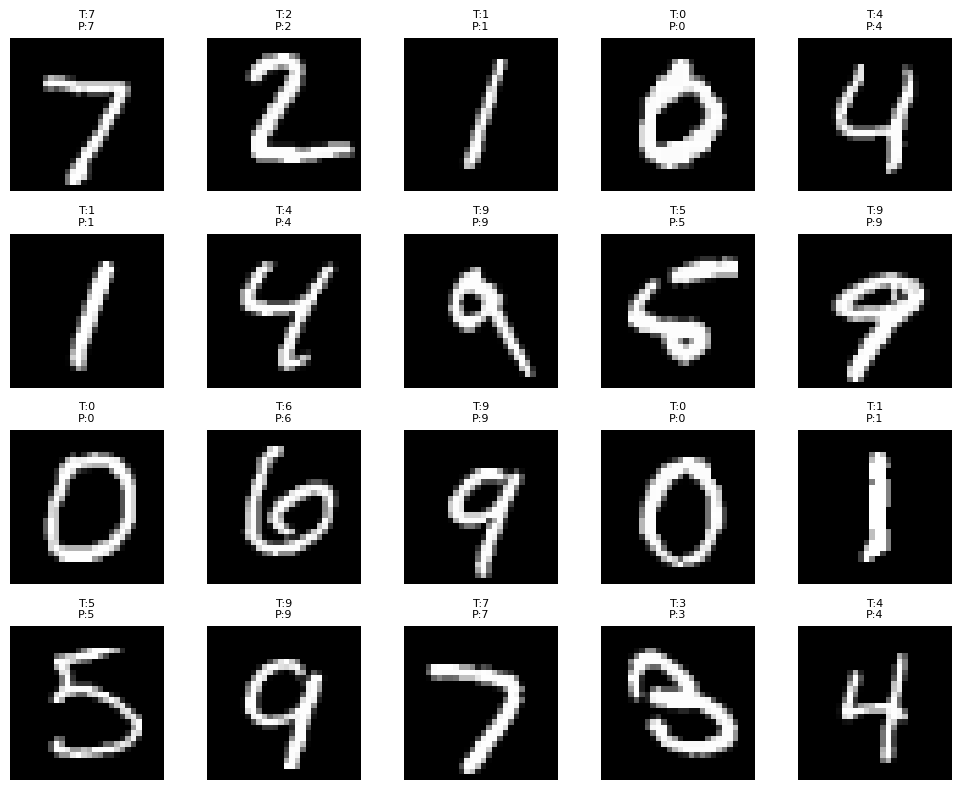

In [66]:
%matplotlib inline
import matplotlib.pyplot as plt
import math

def plot_images_grid(images, true_labels, pred_labels=None, start=0, end=50, columns=10, x_size=2, y_size=2):
    n_images = end - start
    rows = math.ceil(n_images / columns)
    plt.figure(figsize=(columns*x_size, rows*y_size))

    for i, idx in enumerate(range(start, end)):
        plt.subplot(rows, columns, i+1)
        plt.imshow(images[idx], cmap='gray')  # grayscale
        title = f"T:{true_labels[idx]}"
        if pred_labels is not None:
            title += f"\nP:{pred_labels[idx]}"
        plt.title(title, fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_images_grid(x_test, y_test, y_pred, start=0, end=20, columns=5)
